# Neural Network

In [1]:
import numpy as np
from numpy.typing import NDArray
import matplotlib.pyplot as plt

from logistic_regression import LogisticRegression

from utils import *

## Load Data

In [ ]:
X, y = load_data_npy()
# print ('The first element of X is: ', X[0])

The first element of X is:  [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+

In [4]:
print ('The first element of y is: ', y[0,0])
print ('The last element of y is: ', y[-1,0])
print ('The shape of X is: ' + str(X.shape))
print ('The shape of y is: ' + str(y.shape))

The first element of y is:  0
The last element of y is:  1
The shape of X is: (1000, 400)
The shape of y is: (1000, 1)


## Visualizate the data

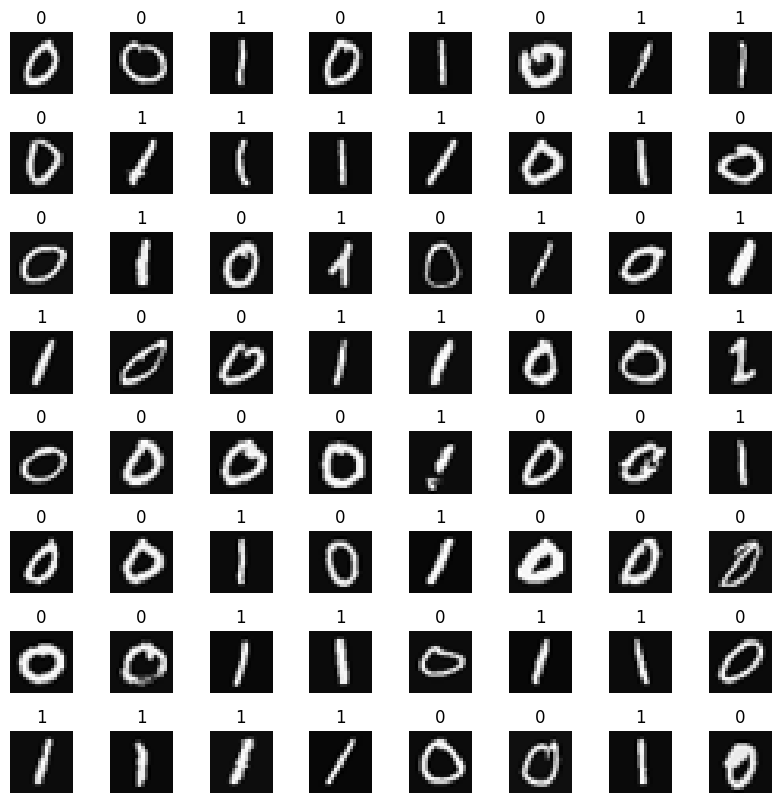

In [5]:
m, n = X.shape

fig, axes = plt.subplots(8,8, figsize=(8,8))
fig.tight_layout(pad=0.1)

for i,ax in enumerate(axes.flat):
    # Select random indices
    random_index = np.random.randint(m)
    
    # Select rows corresponding to the random indices and
    # reshape the image
    X_random_reshaped = X[random_index].reshape((20,20)).T
    
    # Display the image
    ax.imshow(X_random_reshaped, cmap='gray')
    
    # Display the label above the image
    ax.set_title(y[random_index,0])
    ax.set_axis_off()

In [46]:
from abc import abstractmethod
from typing import Tuple

class NerveCellActivation:
    def __init__(self):
        pass

    @abstractmethod
    def forward(self, X: NDArray, w: NDArray, b: float):
        pass

class SigmoidActivation(NerveCellActivation):
    def sigmoid(self, z: float) -> float:
        g = 1 / (1 + np.exp(-z))
        return g

    def forward(self, X: NDArray, w: NDArray, b: float) -> float:
        # if w.shape[1] != n:
        #     raise ValueError('w shape is not equal to X_train shape')
        z = np.dot(w, X) + b
        return self.sigmoid(z)

class NeuralLayer:
    def __init__(self, units: int, activation: NerveCellActivation):
        self.units = units
        self.activation = activation
        self.w = np.array([])
        self.b = np.array([])
    
    def init_weights(self, m: int):
        self.w = 0.01 * (np.random.randn(self.units, m) - 0.5)
        self.b = np.random.randn(self.units).T
    
    def forward(self, X: NDArray) -> NDArray:
        m = X.shape[0]
        if self.b.size == 0 or self.w.size == 0:
            self.init_weights(m)

        a = np.zeros(self.units)
        for i in range(self.units):
            a[i] = self.activation.forward(X, self.w[i], self.b[i])

        return a

class NeuralNetwork:
    def __init__(self, X: NDArray, y: NDArray):
        self.X = X
        self.y = y
        self.m_in = X.shape[0]
        self.layers = []
    
    def add_layer(self, layer: NeuralLayer):
        self.layers.append(layer)
    
    def fit(self) -> NDArray:
        p_hat = np.random.rand(self.m_in, self.layers[-1].units)
        for i in range(self.m_in):
            a = self.X[i]
            for layer in self.layers:
                a = layer.forward(a)
            p_hat[i] = a
        
        return p_hat

print(f'X shape: {X.shape}')
nn = NeuralNetwork(X, y)
nn.add_layer(NeuralLayer(100, SigmoidActivation()))
nn.add_layer(NeuralLayer(64, SigmoidActivation()))
nn.add_layer(NeuralLayer(2, SigmoidActivation()))
p_hat = nn.fit()
print(f'p_hat shape: {p_hat.shape}')
print(f'p_hat[0:2]: {p_hat}')

X shape: (1000, 400)
p_hat shape: (1000, 2)
p_hat[0:2]: [[0.20311594 0.22489185]
 [0.20305706 0.22486921]
 [0.20304679 0.22486581]
 ...
 [0.20325852 0.22496365]
 [0.2032918  0.2249729 ]
 [0.20333885 0.22499665]]
